# ***Capstone project : Predict Mental Health Risk of any idividual.***

## **Problem statement :** Can I identify and predict Mental Health Risk factors which is a serious global challenge ? The  conditions like  Anxiety and Depression are the most common disorders globally and saw a massive surge in prevalence over the past three decades

# CRISP-DM Framework

I will use a standard framework CRISP-DM for this data project. This framework provides a step-by-step process for working through a data problem.



# STEP 1: Problem/Business understanding -->> Define Data problem

Data understanding --->>Researchers and healthcare providers use workplace conditions and socioeconomic data as powerful, non-clinical predictors to assess the risk of mental health conditions

# STEP 2: Data understanding

## Sub-Steps to follow

* **Explore Data:** Conduct Exploratory Data Analysis (EDA) to dive deeper. This involves calculating basic statistics, visualizing distributions, and identifying relationships between variables.
* **Load Initial Data:** Observe the necessary datasets from by Kaggel .
* **Describe Data:** Examine the data properties: data formats, number of records, field identities (e.g., column names), and data types (numeric, nominal).
* **Feature Engineering:** For this usecase I will derived features which are related and /or are socioeconomically correlated.
* **Target Class - Balanced? :** Class-Imbalance analysis
* **PCA:** To get more insights to major contributing factors affecting mental illness Risks
* **Data Skewness:** Check data skeweness and take appropriate actions

* **Verify Data Quality:** Assess the data for issues like missing values, errors, inconsistencies, or duplicates. This will help in next data preparation step

# EDA (Exploratory Data Analysys) & Feature Engineering

In [ ]:
import time
import warnings
# from pathlib import Path

!pip install category_encoders
!pip install xgboost
import nbformat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import  RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from category_encoders import BinaryEncoder,OrdinalEncoder
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,  StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.5 MB/s eta 0:00:00


# Data Analysis ####

In [ ]:
mental_health = pd.read_csv("data/mental_health_risk_dataset.csv")
mental_health.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.60,2.80,9.60,7,10,3,7,8,40,5,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.50,2.70,3.00,10,6,9,1,10,31,3,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.10,14.10,7.20,10,5,2,4,7,28,8,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.00,0.50,10.30,2,10,4,8,7,63,9,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.10,2.50,1.20,8,1,8,8,3,28,1,8,3,3,1,0,0,1,0,1,0


In [ ]:
mental_health.info()
mental_health.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

,count,mean,std,min,25%,50%,75%,max
age,"25,000.00",39.07,12.40,18.00,28.00,39.00,50.00,60.00
sleep_hours,"25,000.00",6.51,2.02,3.00,4.80,6.50,8.20,10.00
physical_activity_hours_per_week,"25,000.00",7.52,4.32,0.00,3.80,7.50,11.30,15.00
screen_time_hours_per_day,"25,000.00",6.47,3.17,1.00,3.70,6.50,9.20,12.00
social_support_score,"25,000.00",5.51,2.89,1.00,3.00,5.00,8.00,10.00
work_stress_level,"25,000.00",5.52,2.86,1.00,3.00,6.00,8.00,10.00
academic_pressure_level,"25,000.00",5.45,2.86,1.00,3.00,5.00,8.00,10.00
job_satisfaction_score,"25,000.00",5.47,2.87,1.00,3.00,5.00,8.00,10.00
financial_stress_level,"25,000.00",5.50,2.88,1.00,3.00,5.00,8.00,10.00
working_hours_per_week,"25,000.00",45.05,14.68,20.00,32.00,45.00,58.00,70.00


# Explore relationship of all features with mental_health_risk(target variable) in original dataset

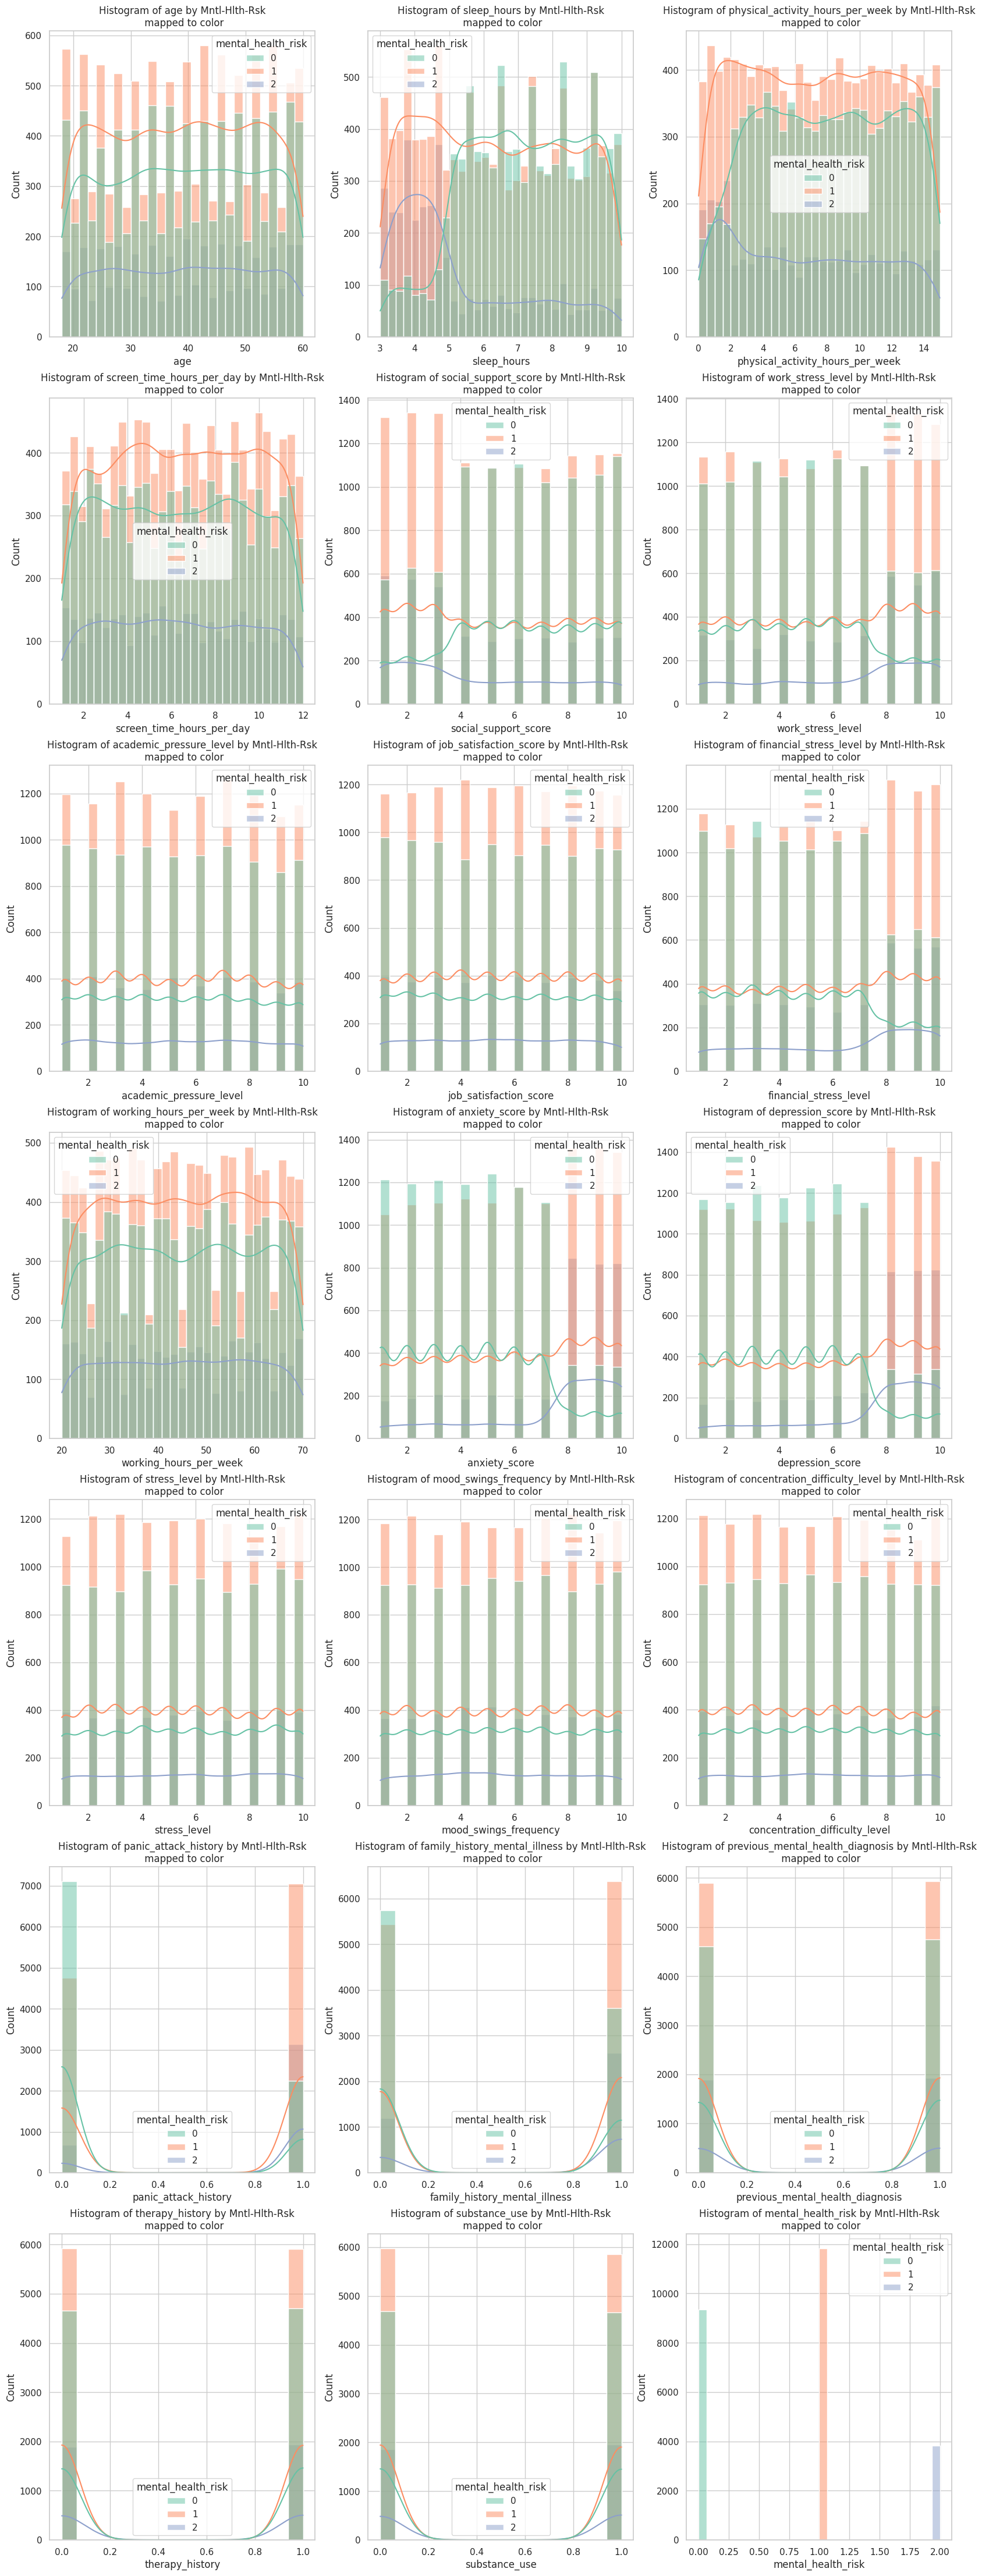

In [ ]:
import math

# Get numeric columns
numeric_cols = mental_health.select_dtypes(include=np.number).columns
n_cols = len(numeric_cols)

# Calculate rows needed for a 3-column wide grid
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(20, 8 * n_rows))

for i, column in enumerate(numeric_cols):
    plt.subplot(n_rows, 3, i + 1)  # Dynamic row count
    #px.box(mental_health, x=column, y="mental_health_risk", color="mental_health_risk",
           #title=f'Boxplot of {column}', labels={column: column, "mental_health_risk": "Mental Health Risk"},
           #color_discrete_sequence=px.colors.qualitative.Set2).show()
    '''sns.boxplot(x=mental_health[column], y=mental_health["mental_health_risk"] #, palette="Set2"
                 ,flierprops={"marker": "x"}, # Change outlier shape
             fliersize=5)
    plt.title(f'Boxplot of {column}')'''
    sns.histplot(data=mental_health, x=column, hue="mental_health_risk", kde=True, palette="Set2")
    plt.title(f'Histogram of {column} by Mntl-Hlth-Rsk\n mapped to color')
    plt.xlabel(column)
    plt.ylabel("Count")

# plt.tight_layout()
plt.show()


# STEP 3: Data Preparation & continue EDA further with new feature engineered data

### FEATURE ENGINEERING & CREATE DERIVED COLUMNS

# Derived column definition

<table style="border-collapse: collapse; border: 1px solid black; width: 100%;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid black; padding: 8px;">SourceColumn</th>
      <th style="border: 1px solid black; padding: 8px;">DerivedColumn</th>
    </tr>
  </thead>
<tbody>
  <tr>
    <td style="border: 1px solid black; padding: 8px;"> anxiety_score |  depression_score | stress_level </td>
    <td style="border: 1px solid black; padding: 8px;">total_distress_score</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">work_stress_level | academic_pressure_level | financial_stress_level</td>
    <td style="border: 1px solid black; padding: 8px;">situational_stress_load</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 8px;">working_hours_per_week | sleep_hours</td>
    <td style= "border: 1px solid black; padding: 8px;">work_to_sleep_ratio</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">physical_activity_hours_per_week | screen_time_hours_per_day</td>
    <td style= "border: 1px solid black; padding: 8px;">work_to_sleep_ratio</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">panic_attack_history | family_history_mental_illness | previous_mental_health_diagnosis | substance_use | therapy_history</td>
    <td style= "border: 1px solid black; padding: 8px;">clinical_vulnerability_index</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">social_support_score | job_satisfaction_score | work_stress_level</td>
    <td style= "border: 1px solid black; padding: 8px;">protective_buffer_score</td>
  </tr>
  <tr>
    <td style= "border: 1px solid black; padding: 8px;">age</td>
    <td style= "border: 1px solid black; padding: 8px;">age_group</td>
  </tr>
 </tbody>

</table>


In [ ]:
# Make a copy to apply feature engineering without modifying the original sample_data
new_data_engineered_df = mental_health.copy()

# ==========================================
# 1. COMPOSITE CLINICAL & PSYCHOLOGICAL SCORES
# ==========================================
new_data_engineered_df['total_distress_score'] = new_data_engineered_df['anxiety_score'] + new_data_engineered_df['depression_score'] + new_data_engineered_df['stress_level']
new_data_engineered_df['situational_stress_load'] = new_data_engineered_df['work_stress_level'] + new_data_engineered_df['academic_pressure_level'] + new_data_engineered_df['financial_stress_level']


# ==========================================
# 2. LIFESTYLE BALANCE & INTERACTION METRICS
# ==========================================
new_data_engineered_df['work_to_sleep_ratio'] = new_data_engineered_df['working_hours_per_week'] / (new_data_engineered_df['sleep_hours'] * 7 + 1)
new_data_engineered_df['active_vs_screen_ratio'] = (new_data_engineered_df['physical_activity_hours_per_week'] / 7) / (new_data_engineered_df['screen_time_hours_per_day'] + 1)

# ==========================================
# 3. CLINICAL BACKGROUND & VULNERABILITY INDEX
# ==========================================
history_cols_new = ['panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'substance_use','therapy_history']
new_data_engineered_df['clinical_vulnerability_index'] = new_data_engineered_df[history_cols_new].sum(axis=1)
new_data_engineered_df['protective_buffer_score'] = (new_data_engineered_df['social_support_score'] + new_data_engineered_df['job_satisfaction_score']) - new_data_engineered_df['work_stress_level']

# ==========================================
# 4. CATEGORICAL ENCODING & DEMOGRAPHICS
# ==========================================
new_data_engineered_df['age_group'] = pd.cut(new_data_engineered_df['age'],
                         bins=[0, 24, 34, 50, 100],
                         labels=['Youth', 'Young_Adult', 'Adult', 'Senior'])


# ==========================================
# 5. TARGET COLUMN CATEGORICAL LABEL
# ==========================================
# Define your bins and labels
bins = [-1,0,1, 2]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Apply mapping to your dataframe column
new_data_engineered_df['risk_level'] = pd.cut(new_data_engineered_df['mental_health_risk'], bins=bins, labels=labels)

# Identify all numeric columns after feature engineering
# This will include original numeric columns and newly created numeric columns
numeric_cols_for_prediction = new_data_engineered_df.select_dtypes(include=[np.number]).columns.tolist()


# New derived numeric features
new_numeric_derived_features = ['total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio',
                                'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score',
                                'age_group']
other_features_from_original_dataset = ['gender','marital_status','education_level','employment_status','mood_swings_frequency'
                                  ,'concentration_difficulty_level','mental_health_risk','risk_level']
# Combine all numeric features for the model input
all_features_for_model = other_features_from_original_dataset + new_numeric_derived_features


print("Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):")
display(new_data_engineered_df[all_features_for_model].head())
new_data_engineered_df[all_features_for_model].shape


Engineered new data (first 5 rows, showing only features relevant for prediction by the current model):


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,Other,Single,Bachelor,Unemployed,8,3,1,Medium Risk,17,21,0.65,0.04,4,4,Senior
1,Male,Single,Bachelor,Unemployed,9,3,0,Low Risk,14,25,0.95,0.10,0,5,Adult
2,Female,Divorced,Bachelor,Student,4,2,2,High Risk,12,14,1.23,0.25,5,9,Senior
3,Other,Married,Bachelor,Employed,2,5,2,High Risk,22,21,1.26,0.01,4,0,Senior
4,Male,Single,High School,Self-Employed,3,1,0,Low Risk,12,12,0.76,0.16,2,15,Senior


(25000, 15)

# CHECK IF NEW ENGINEERED DATASET HAS ANY NULL VALUES

In [ ]:
new_data_engineered_df[all_features_for_model].isna().sum()

,0
gender,0
marital_status,0
education_level,0
employment_status,0
mood_swings_frequency,0
concentration_difficulty_level,0
mental_health_risk,0
risk_level,0
total_distress_score,0
situational_stress_load,0


# Result indicates no NULL values

In [ ]:
# Create a final feature engineered dataframe
mental_health_engineered_final_df = new_data_engineered_df[all_features_for_model]
mental_health_engineered_final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   gender                          25000 non-null  object  
 1   marital_status                  25000 non-null  object  
 2   education_level                 25000 non-null  object  
 3   employment_status               25000 non-null  object  
 4   mood_swings_frequency           25000 non-null  int64   
 5   concentration_difficulty_level  25000 non-null  int64   
 6   mental_health_risk              25000 non-null  int64   
 7   risk_level                      25000 non-null  category
 8   total_distress_score            25000 non-null  int64   
 9   situational_stress_load         25000 non-null  int64   
 10  work_to_sleep_ratio             25000 non-null  float64 
 11  active_vs_screen_ratio          25000 non-null  float64 
 12  clinical_vulnerabi

# Identify numeric & categorical coulmns in new feature engineered dataset

In [ ]:
# Identify numeric & categorical columns

categorical_cols = mental_health_engineered_final_df.select_dtypes(include=["object","category"]).columns
numeric_cols = mental_health_engineered_final_df.select_dtypes(include=[np.number]).columns
# risk_level is created to use in plots &  not required for modelling
categorical_cols = [col for col in categorical_cols if col != 'risk_level']
print("\nCategorical columns:")
print(categorical_cols)
print("\nNumeric columns:")
print(numeric_cols)


Categorical columns:
['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']

Numeric columns:
Index(['mood_swings_frequency', 'concentration_difficulty_level',
       'mental_health_risk', 'total_distress_score', 'situational_stress_load',
       'work_to_sleep_ratio', 'active_vs_screen_ratio',
       'clinical_vulnerability_index', 'protective_buffer_score'],
      dtype='object')


# CHECK DATA SKEWNESS

In [ ]:
# find any data skewness

"""
    Calculate skewness for all numeric columns

    Interpretation:
    - Skewness = 0: Perfectly symmetric (normal distribution)
    - -0.5 to 0.5: Fairly symmetric
    - 0.5 to 1 or -1 to -0.5: Moderately skewed
    - > 1 or < -1: Highly skewed
    """
# BELOW INDICATES INPUT FEATURES  LOOKS SKEWED

skewness = mental_health_engineered_final_df[numeric_cols].skew()
print("Skewness of numeric features:")
print(skewness)

Skewness of numeric features:
mood_swings_frequency            -0.00
concentration_difficulty_level    0.01
mental_health_risk                0.32
total_distress_score              0.01
situational_stress_load           0.01
work_to_sleep_ratio               1.04
active_vs_screen_ratio            1.80
clinical_vulnerability_index     -0.02
protective_buffer_score           0.02
dtype: float64


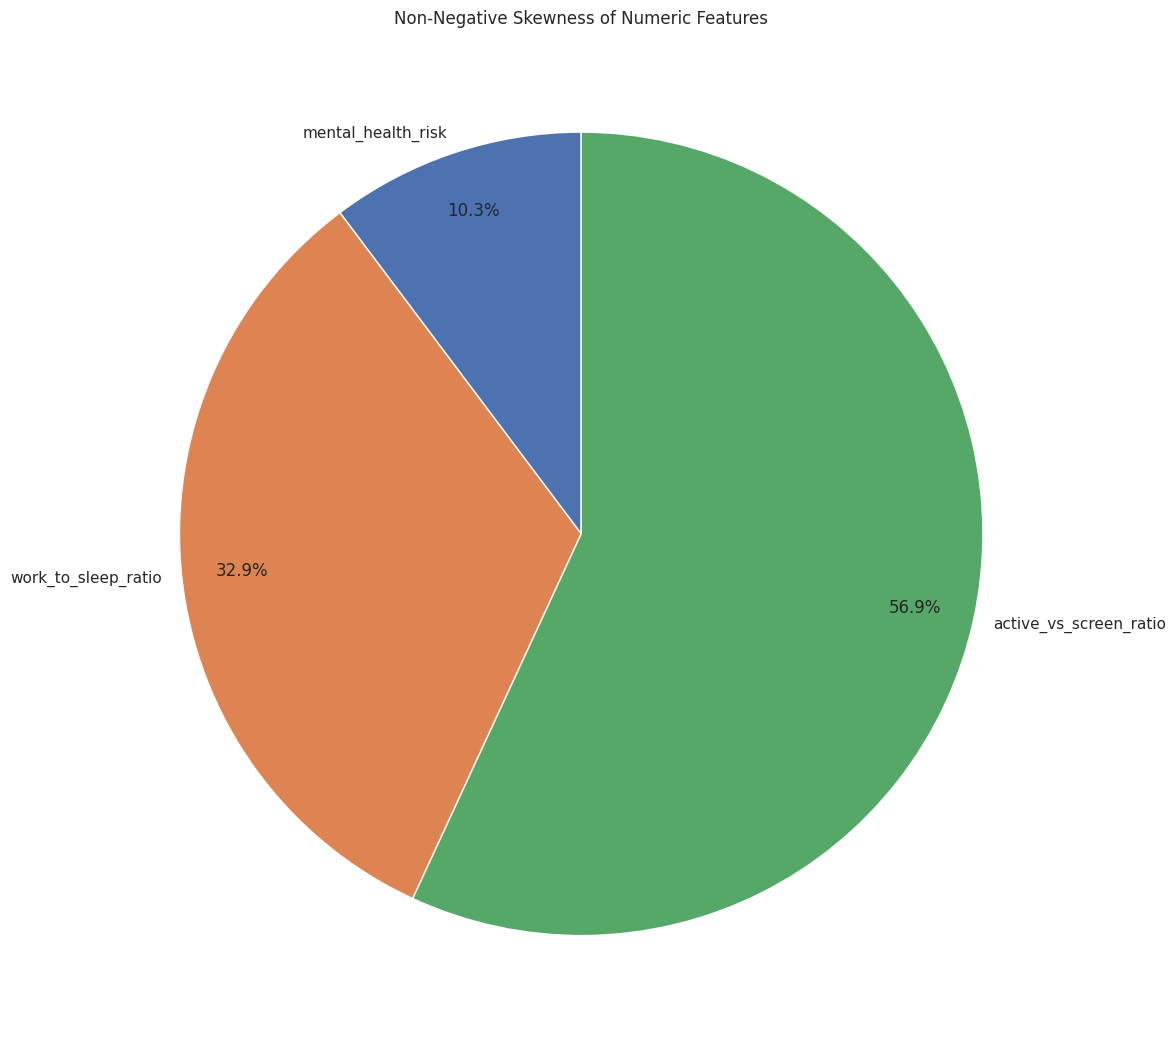

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out negative skewness values for pie chart
plot_skewness = mental_health_engineered_final_df[numeric_cols].skew()
positive_skewness = plot_skewness[plot_skewness > 0.02]

plt.figure(figsize=(12, 12)) # Increased figure size
plt.pie(positive_skewness,
        labels=positive_skewness.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85, # Distance of percentage labels from center
        labeldistance=1.05) # Distance of text labels from center
plt.title('Non-Negative Skewness of Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
# Get categorical columns vs numeric columns for later use in preprocessing

unique_vals = {col: mental_health_engineered_final_df[col].unique() for col in categorical_cols}

print('DISPLAY UNIQUE VALUES FOR EACH CATEGORICAL FEATURE ')
for key, value in unique_vals.items():
    print(f"{key}: {value}")



DISPLAY UNIQUE VALUES FOR EACH CATEGORICAL FEATURE 
gender: ['Other' 'Male' 'Female']
marital_status: ['Single' 'Divorced' 'Married']
education_level: ['Bachelor' 'High School' 'Master' 'PhD']
employment_status: ['Unemployed' 'Student' 'Employed' 'Self-Employed']
age_group: ['Senior', 'Adult', 'Youth', 'Young_Adult']
Categories (4, object): ['Youth' < 'Young_Adult' < 'Adult' < 'Senior']


# Class-Imbalance analysis

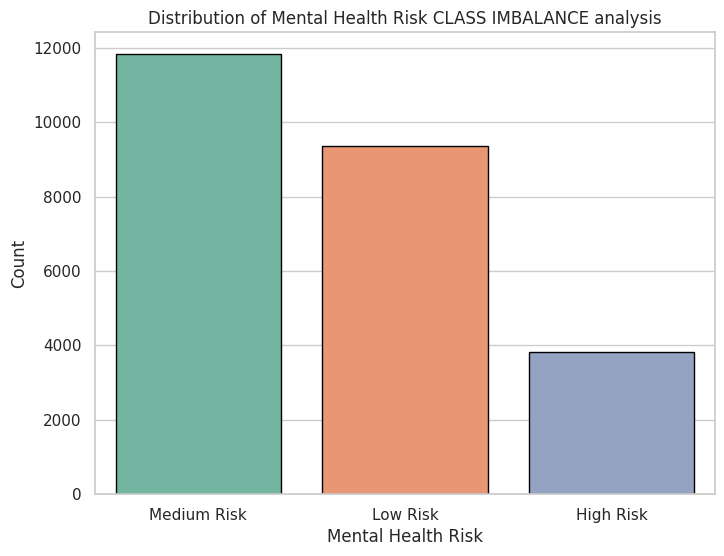

In [ ]:
# Class Imbalance Evaluation. Target distribution pattern is important to understand for model selection and evaluation.
# map the target variable to more descriptive labels for better visualization
mental_health_for_plt = mental_health_engineered_final_df.copy()
mental_health_for_plt["mental_health_risk"] = mental_health_engineered_final_df["mental_health_risk"].map({0: "Low Risk", 1: "Medium Risk", 2: "High Risk"})

plt.figure(figsize=(8, 6))
sns.countplot(data=mental_health_for_plt, x="mental_health_risk", palette="Set2", edgecolor="black",)
plt.title("Distribution of Mental Health Risk CLASS IMBALANCE analysis")
plt.xlabel("Mental Health Risk")
plt.ylabel("Count")
plt.show()

#### USE OrdinalEncoder for categorical features
***Didn't use preprocessor OneHotEncoder or BinaryEncoder to keep the dimentionality unchanged/under control for PCA and HEAT MAP. This will give better readability***

***So using category_encoders' OrdinalEncoder for all categorical features***

In [ ]:
encoder = OrdinalEncoder()  # using this from category_encoders instead of sklearn's OrdinalEncoder to handle unknown categories gracefully during transformation
df_encoded = mental_health_engineered_final_df.copy()
df_encoded[categorical_cols] = encoder.fit_transform(df_encoded[categorical_cols])
print("\nDataFrame after ordinal encoding:")
display(df_encoded.head())
display(df_encoded.isna().sum())
display(df_encoded.describe().T)


DataFrame after ordinal encoding:


,gender,marital_status,education_level,employment_status,mood_swings_frequency,concentration_difficulty_level,mental_health_risk,risk_level,total_distress_score,situational_stress_load,work_to_sleep_ratio,active_vs_screen_ratio,clinical_vulnerability_index,protective_buffer_score,age_group
0,1,1,1,1,8,3,1,Medium Risk,17,21,0.65,0.04,4,4,4
1,2,1,1,1,9,3,0,Low Risk,14,25,0.95,0.10,0,5,3
2,3,2,1,2,4,2,2,High Risk,12,14,1.23,0.25,5,9,4
3,1,3,1,3,2,5,2,High Risk,22,21,1.26,0.01,4,0,4
4,2,1,2,4,3,1,0,Low Risk,12,12,0.76,0.16,2,15,4


,0
gender,0
marital_status,0
education_level,0
employment_status,0
mood_swings_frequency,0
concentration_difficulty_level,0
mental_health_risk,0
risk_level,0
total_distress_score,0
situational_stress_load,0


,count,mean,std,min,25%,50%,75%,max
gender,"25,000.00",2.00,0.81,1.00,1.00,2.00,3.00,3.00
marital_status,"25,000.00",2.01,0.81,1.00,1.00,2.00,3.00,3.00
education_level,"25,000.00",2.49,1.12,1.00,1.00,2.00,3.00,4.00
employment_status,"25,000.00",2.50,1.12,1.00,2.00,3.00,3.00,4.00
mood_swings_frequency,"25,000.00",5.51,2.87,1.00,3.00,6.00,8.00,10.00
concentration_difficulty_level,"25,000.00",5.49,2.87,1.00,3.00,5.00,8.00,10.00
mental_health_risk,"25,000.00",0.78,0.69,0.00,0.00,1.00,1.00,2.00
total_distress_score,"25,000.00",16.57,4.99,3.00,13.00,17.00,20.00,30.00
situational_stress_load,"25,000.00",16.46,4.96,3.00,13.00,16.00,20.00,30.00
work_to_sleep_ratio,"25,000.00",1.08,0.52,0.28,0.68,0.97,1.34,3.18


# PCA analysis to find the most important features

#### DEFINE A FUNCTION FOR PCA ANALYSIS

In [ ]:
from sklearn.decomposition import PCA


def apply_pca_and_plot_variance(X_scaled, df, palette,type_text):

# Apply PCA
    pca = PCA(n_components=None) # Keep all components for now to examine variance
    pca.fit(X_scaled)

    # Explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    print(f"Explained variance ratio of each component - {type_text}:", explained_variance_ratio)

    # Cumulative explained variance
    cum_explained_variance = np.cumsum(explained_variance_ratio)
    print(f"Cumulative explained variance - {type_text}:", cum_explained_variance)

    # Plot explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), cum_explained_variance, marker='o', linestyle='--')
    plt.title(f'Cumulative Explained Variance by PCA Components - {type_text}:')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

    # To see which original features contribute to each principal component,
    # you can inspect the `components_` attribute of the PCA model.
    # Each row in `pca.components_` corresponds to a principal component,
    # and each column corresponds to an original feature in the order they were in X_scaled.
    print(f"\nPrincipal Components (loadings) - {type_text}:")
    pca_components_df = pd.DataFrame(pca.components_, columns=df.columns)
    print(pca_components_df.head())

    # For example, to see the features that contribute most to the first principal component:
    print(f"\nTop features contributing to the first principal component - {type_text}:")
    print(pca_components_df.iloc[0].sort_values(ascending=False))

    num_components_to_plot = 5 # You can adjust this number
    plt.figure(figsize=(15, 5 * num_components_to_plot))

    for i in range(num_components_to_plot):
        # Get the loadings for the current principal component
        component_loadings = pca_components_df.iloc[i]

        # Sort by absolute value to find the most influential features
        sorted_loadings = component_loadings.abs().sort_values(ascending=False)

        # Get the top N features (e.g., top 5) and their actual loadings
        top_features = sorted_loadings.head(5).index
        top_loadings = component_loadings[top_features]

        plt.subplot(num_components_to_plot, 1, i + 1)
        sns.barplot(x=top_loadings.index, y=top_loadings.values, palette=palette)
        plt.title(f'Top Feature Contributions to Principal Component {i + 1} - {type_text}:')
        plt.xlabel('Feature')
        plt.ylabel('Loading Value')
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

#### COMPARE BETWEEN NUMERIC ONLY VS NUMERIC & CATEGORICAL COMBINE FEATURE.

### DO THE CATEGORICAL FEATURES HAVE SIGNIFICANT IMPACT IN PCA ANALYSIS FOR THIS USE CASE?

Explained variance ratio of each component - Numeric & Categorical: [0.10228775 0.0798727  0.0790217  0.07829012 0.07758271 0.07716591
 0.07698238 0.07661433 0.07583598 0.07515687 0.07499613 0.07454804
 0.0516454 ]
Cumulative explained variance - Numeric & Categorical: [0.10228775 0.18216044 0.26118214 0.33947226 0.41705496 0.49422088
 0.57120325 0.64781758 0.72365356 0.79881043 0.87380656 0.9483546
 1.        ]


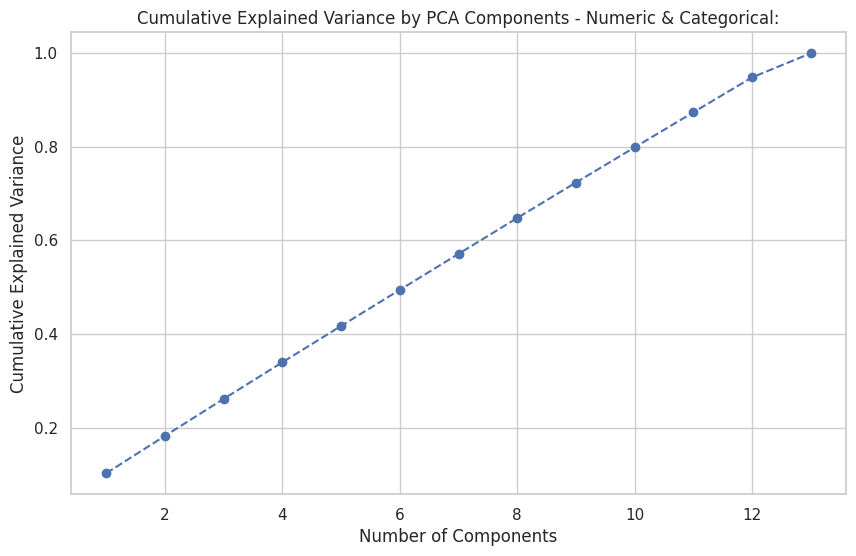


Principal Components (loadings) - Numeric & Categorical:
   gender  marital_status  education_level  employment_status  \
0   -0.02           -0.06             0.01               0.03   
1   -0.21           -0.33             0.41               0.02   
2    0.22           -0.41            -0.48              -0.15   
3    0.39           -0.29             0.06              -0.39   
4   -0.32           -0.40            -0.09               0.27   

   mood_swings_frequency  concentration_difficulty_level  \
0                   0.01                            0.02   
1                   0.02                            0.51   
2                   0.30                            0.13   
3                  -0.35                           -0.23   
4                   0.54                           -0.32   

   total_distress_score  situational_stress_load  work_to_sleep_ratio  \
0                 -0.00                     0.71                -0.03   
1                  0.12                    -

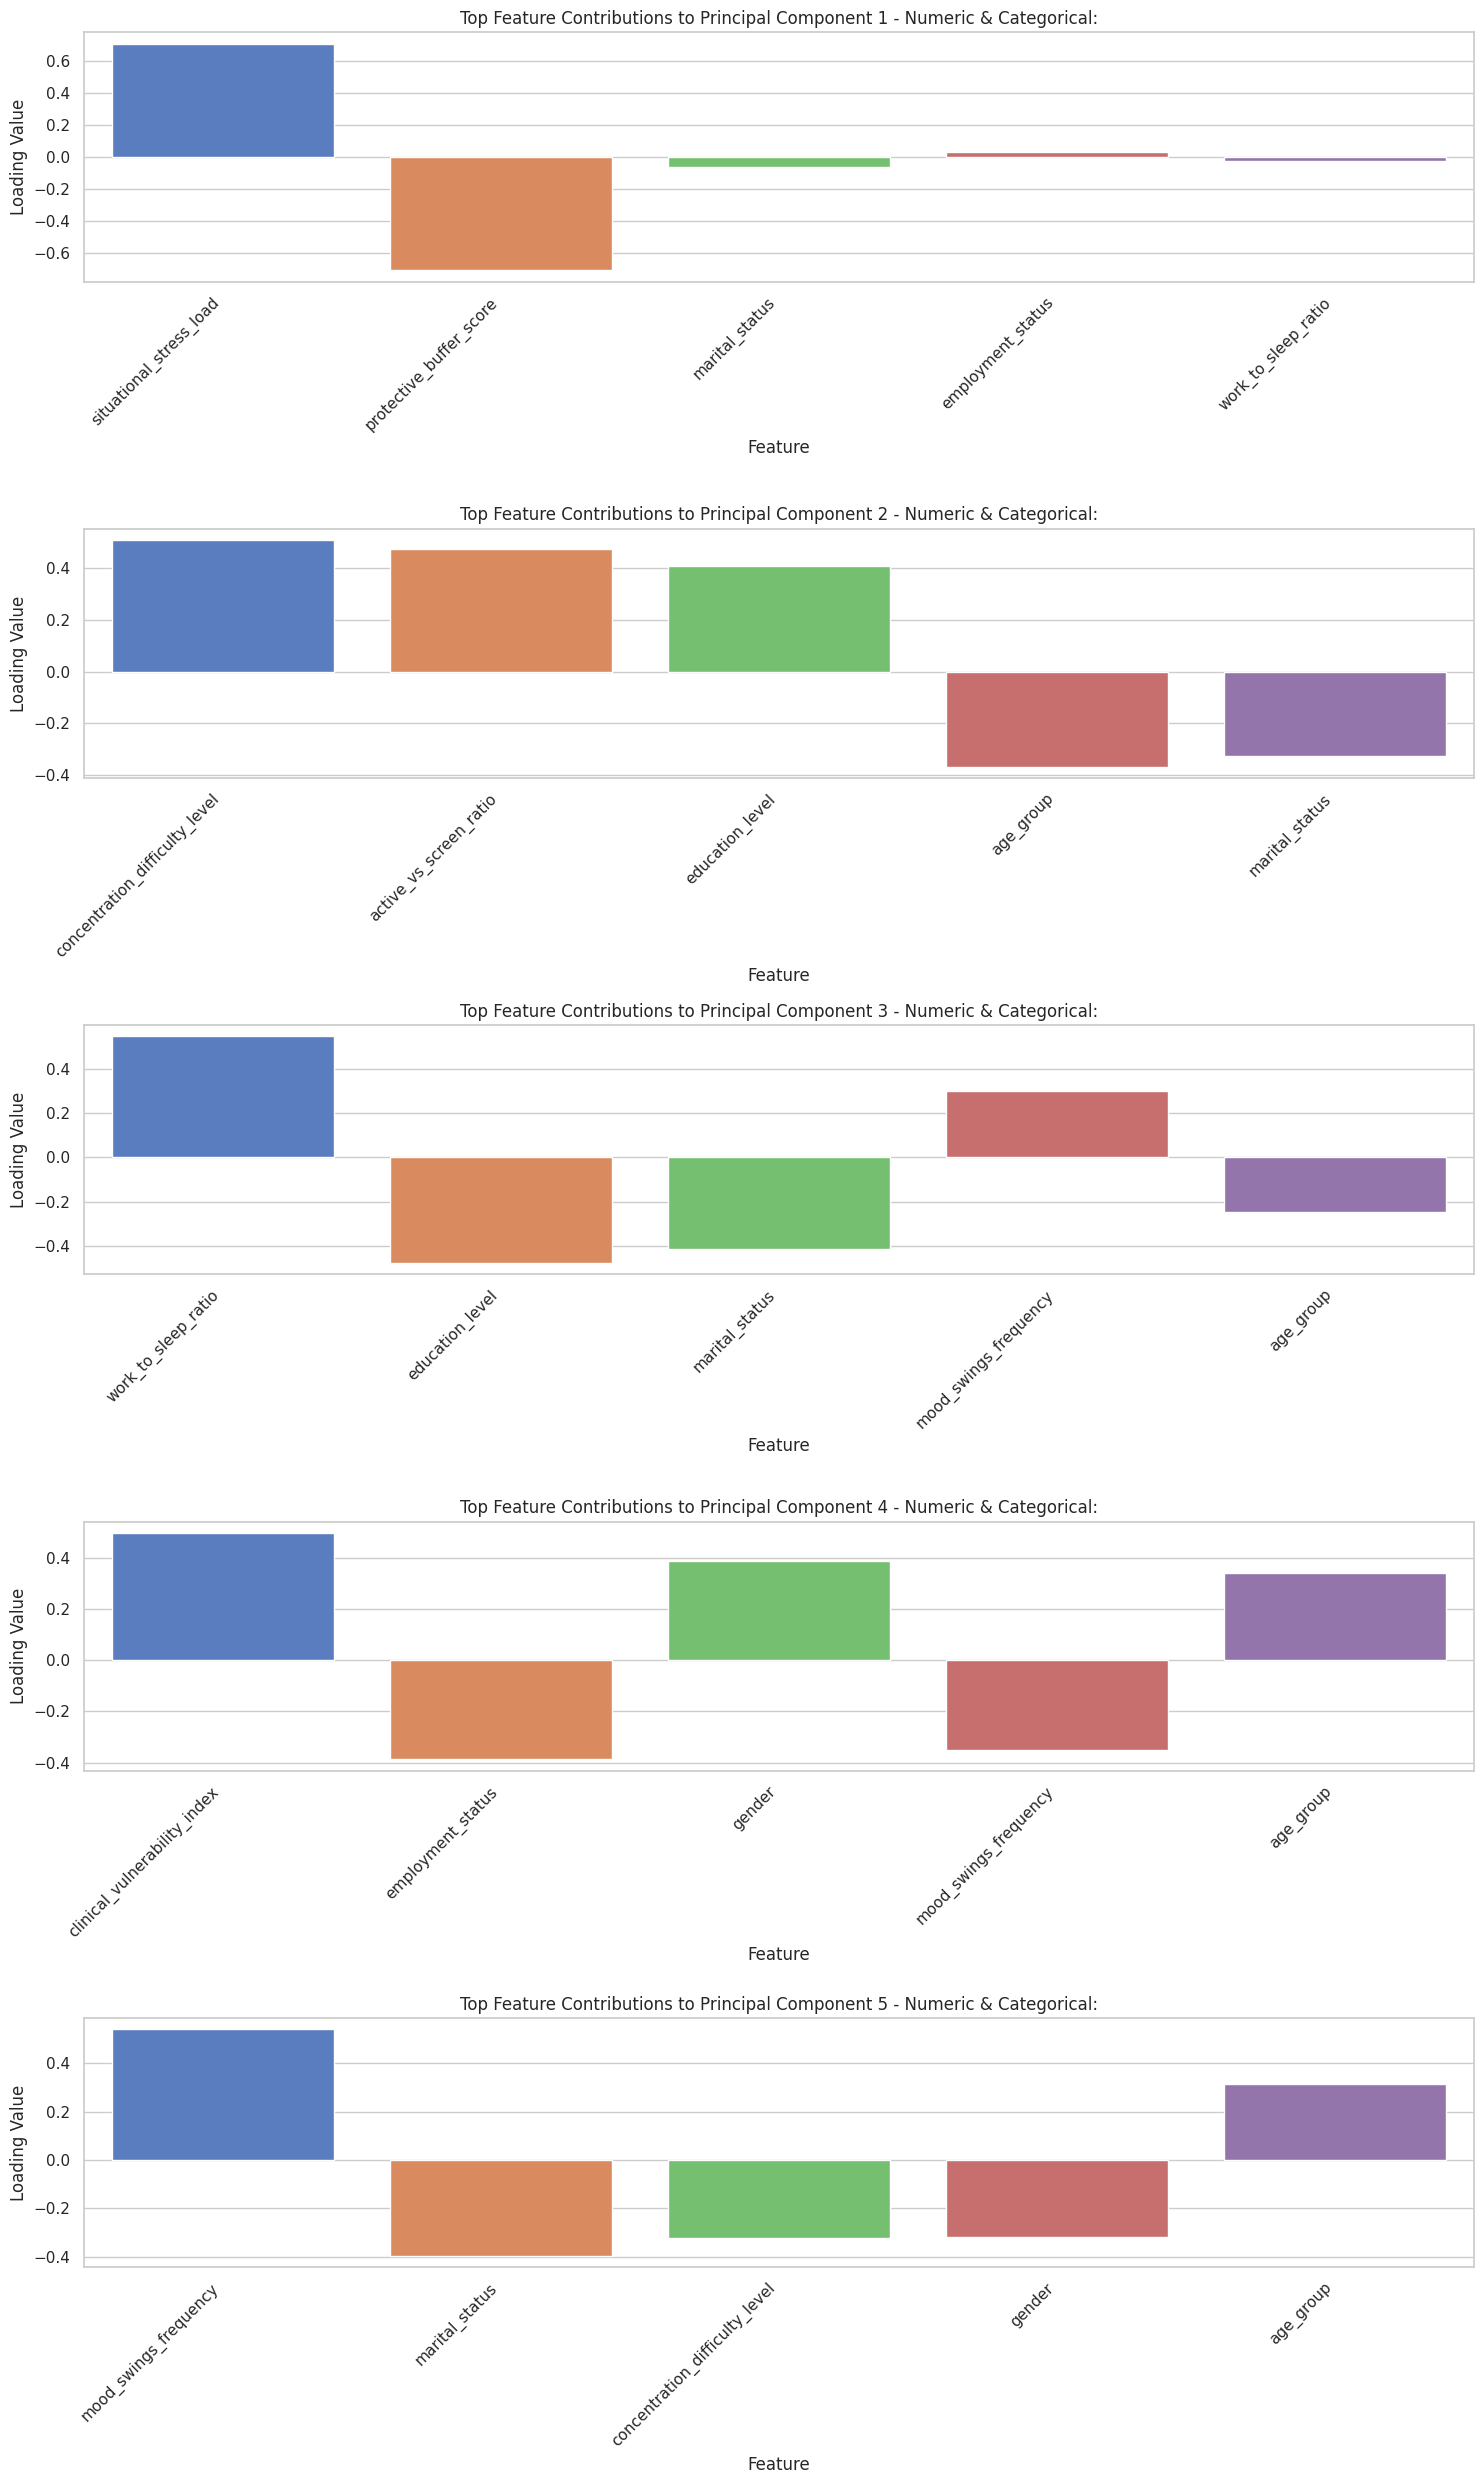

Explained variance ratio of each component - Numeric Only: [0.16600162 0.12656438 0.12623837 0.12498262 0.12482609 0.12411687
 0.12330865 0.08396139]
Cumulative explained variance - Numeric Only: [0.16600162 0.292566   0.41880437 0.54378699 0.66861309 0.79272996
 0.91603861 1.        ]


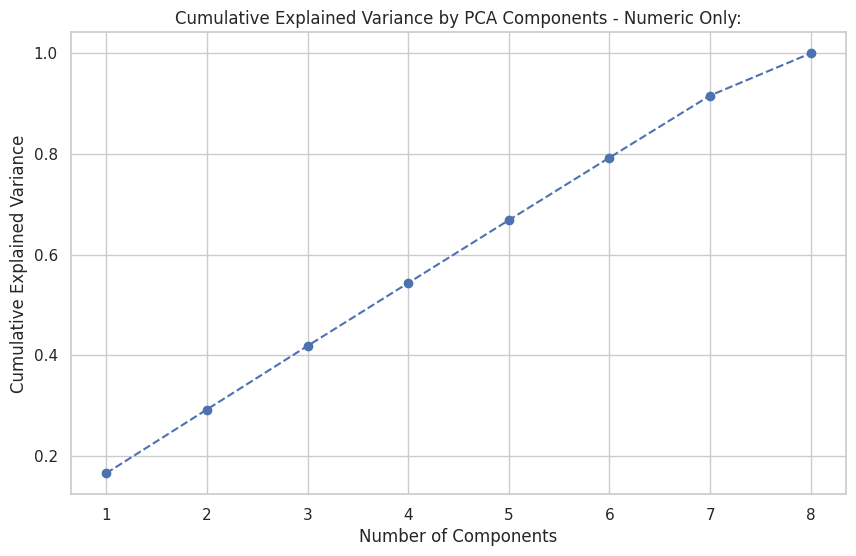


Principal Components (loadings) - Numeric Only:
   mood_swings_frequency  concentration_difficulty_level  \
0                   0.01                            0.02   
1                  -0.54                            0.20   
2                   0.35                            0.64   
3                  -0.35                           -0.04   
4                  -0.18                           -0.13   

   total_distress_score  situational_stress_load  work_to_sleep_ratio  \
0                 -0.00                     0.71                -0.03   
1                  0.35                    -0.01                -0.10   
2                  0.34                    -0.02                 0.26   
3                  0.31                     0.00                 0.77   
4                  0.66                    -0.00                -0.51   

   active_vs_screen_ratio  clinical_vulnerability_index  \
0                   -0.01                          0.01   
1                    0.47        

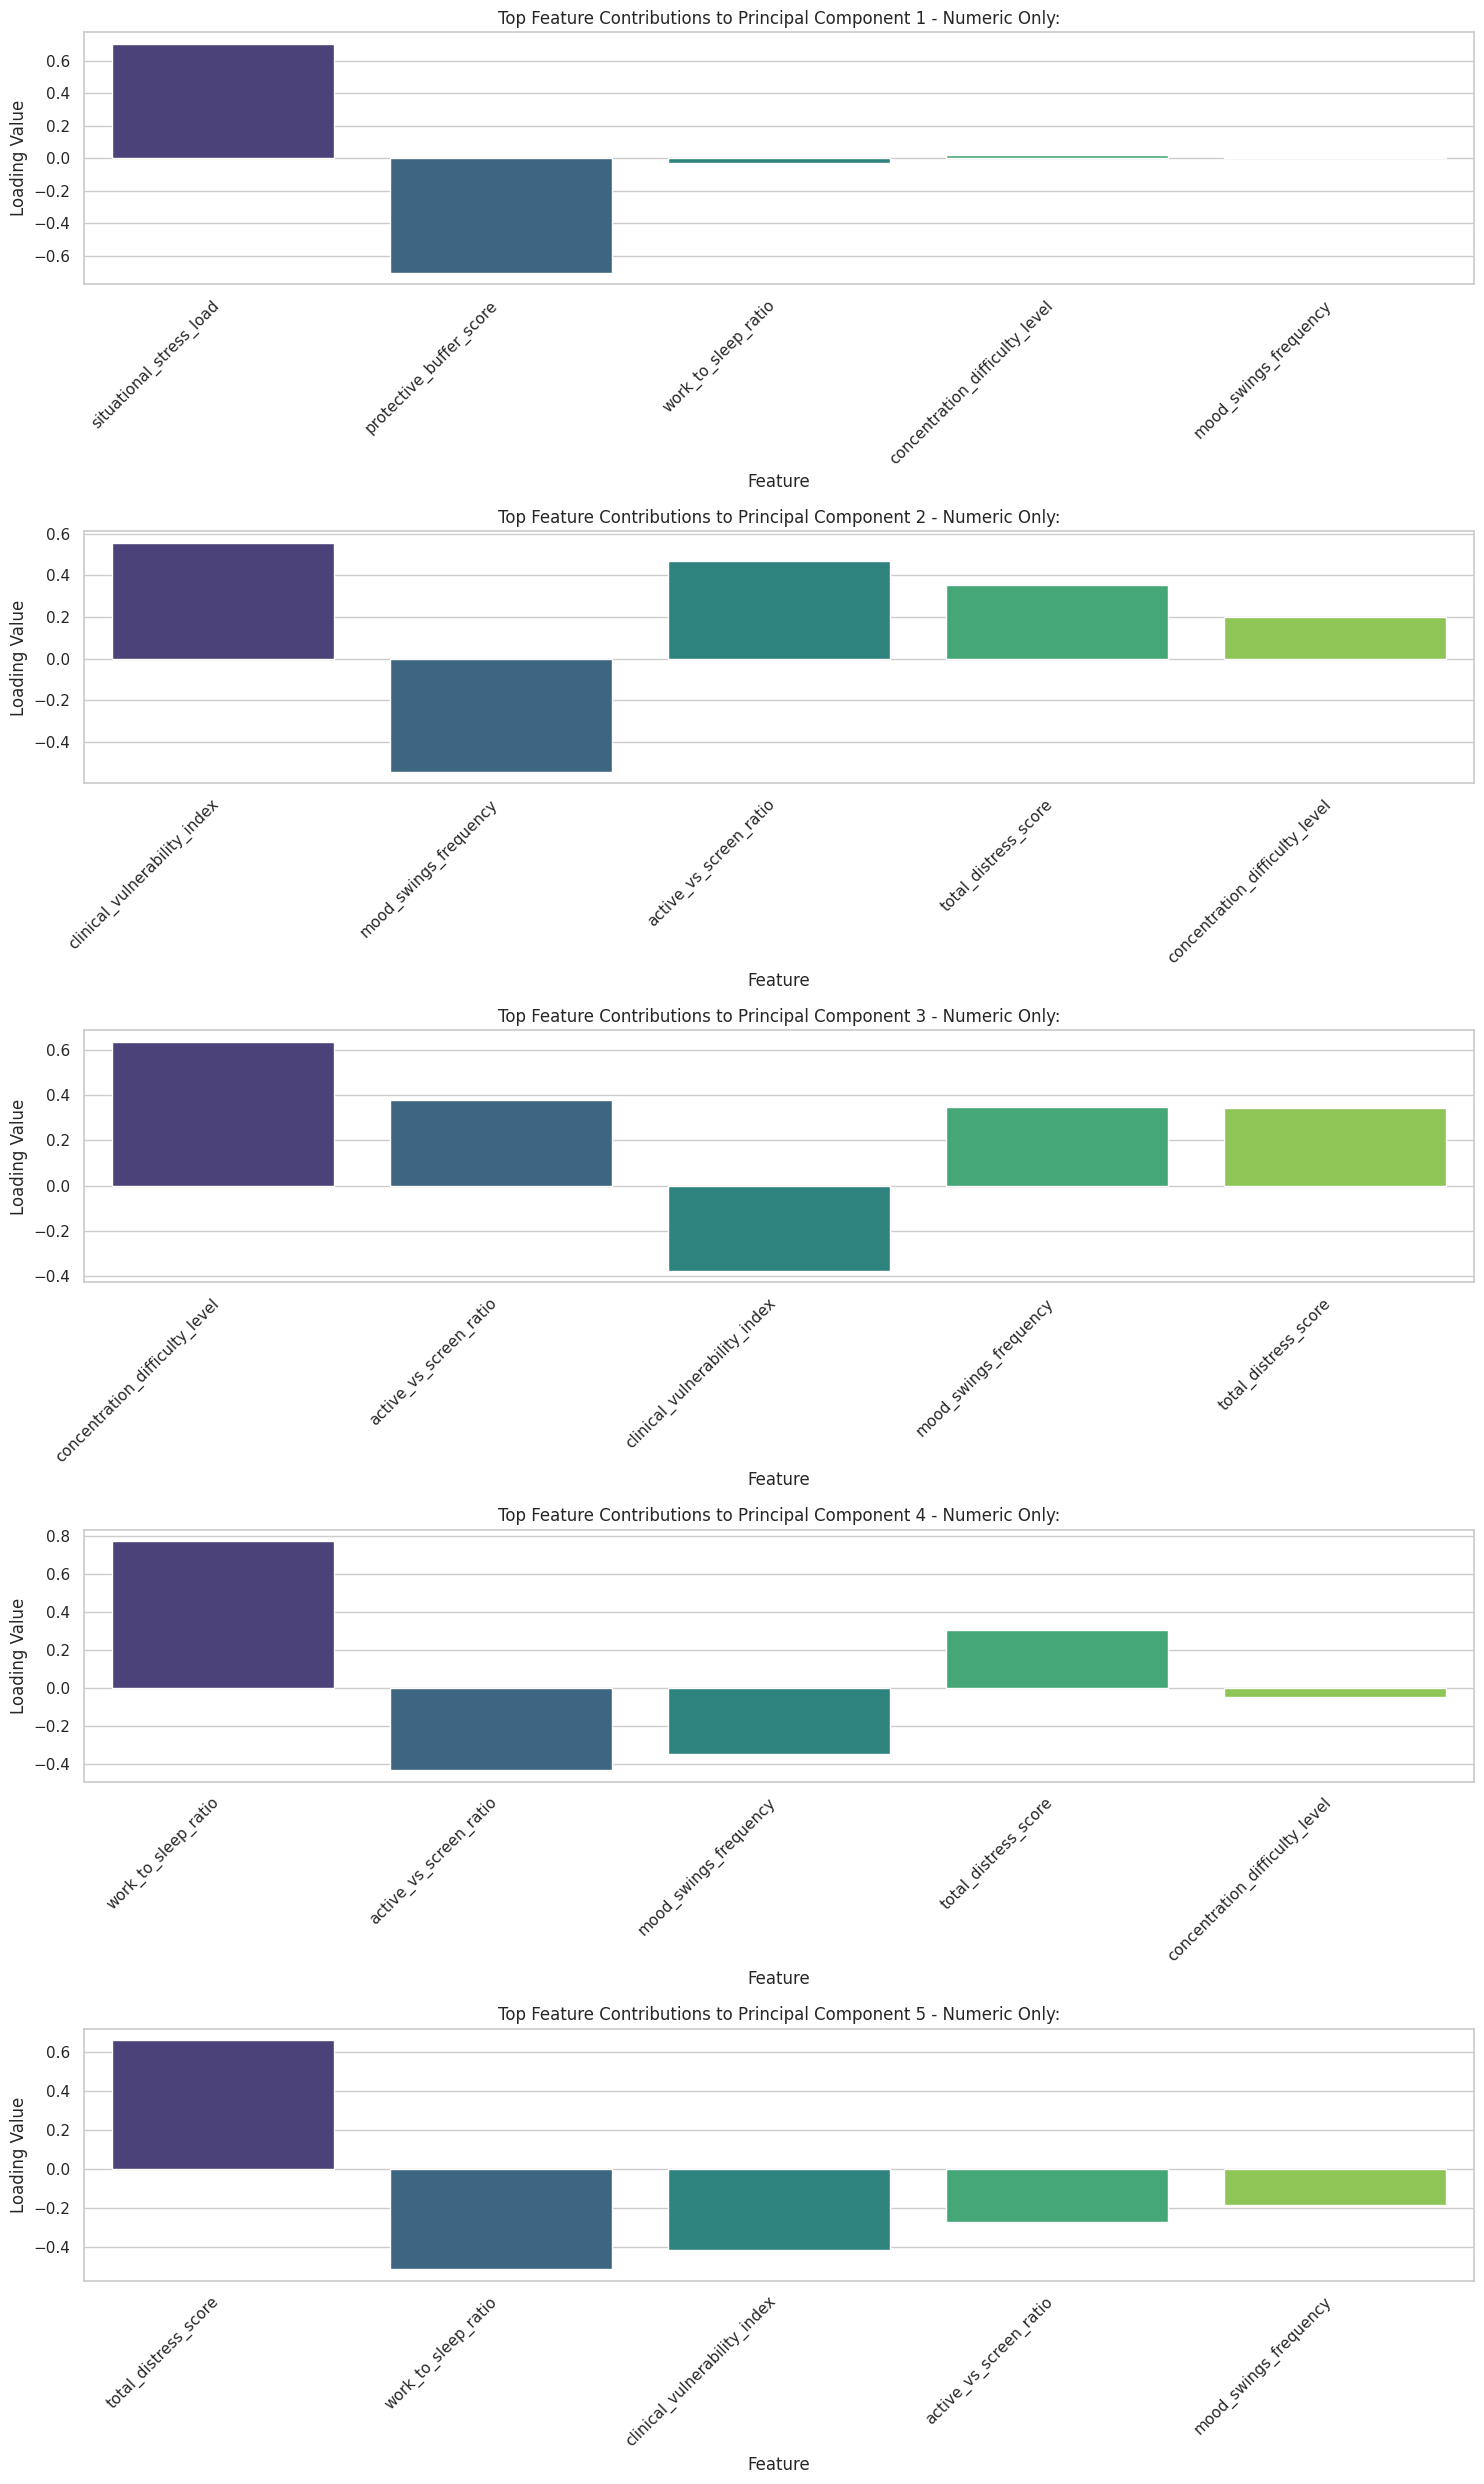

In [ ]:
# df_encoded DF compositoin - categorical columns encoded with OrdinalEncoder + numeric columns

mental_health_pca = df_encoded.drop(columns=['mental_health_risk','risk_level'])
# mental_health_pca = pd.concat([mental_health_pca, mental_health_cat], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(mental_health_pca)
apply_pca_and_plot_variance(X_scaled, mental_health_pca,palette='muted',type_text='Numeric & Categorical')



mental_health_numeric_pca = mental_health_engineered_final_df[numeric_cols].drop(columns='mental_health_risk')
scaler_numeric = StandardScaler()
X_scaled_numeric = scaler_numeric.fit_transform(mental_health_numeric_pca)
apply_pca_and_plot_variance(X_scaled_numeric, mental_health_numeric_pca,palette='viridis',type_text='Numeric Only')


# PCA analysis shows 7- 8 different factors (numeric only) contribute 80-85% to mental illness. Considering categorical &  numeric together,  10-12 features contribute to mental illness

**The first principal component (PC1) is the direction in space along which the data points have the highest or most variance.**

**From the above plots other PCA components like PC2/PC3 shows different important features which have most noticible variances.**

# CHECK INDEPENDENT/DEPENDENT VARIABLE CORELATIONS- HEAT MAP ANALYSIS

### It allows me to instantly visualize which features have the strongest positive or negative relationships with my target, streamlining feature selection and model building.

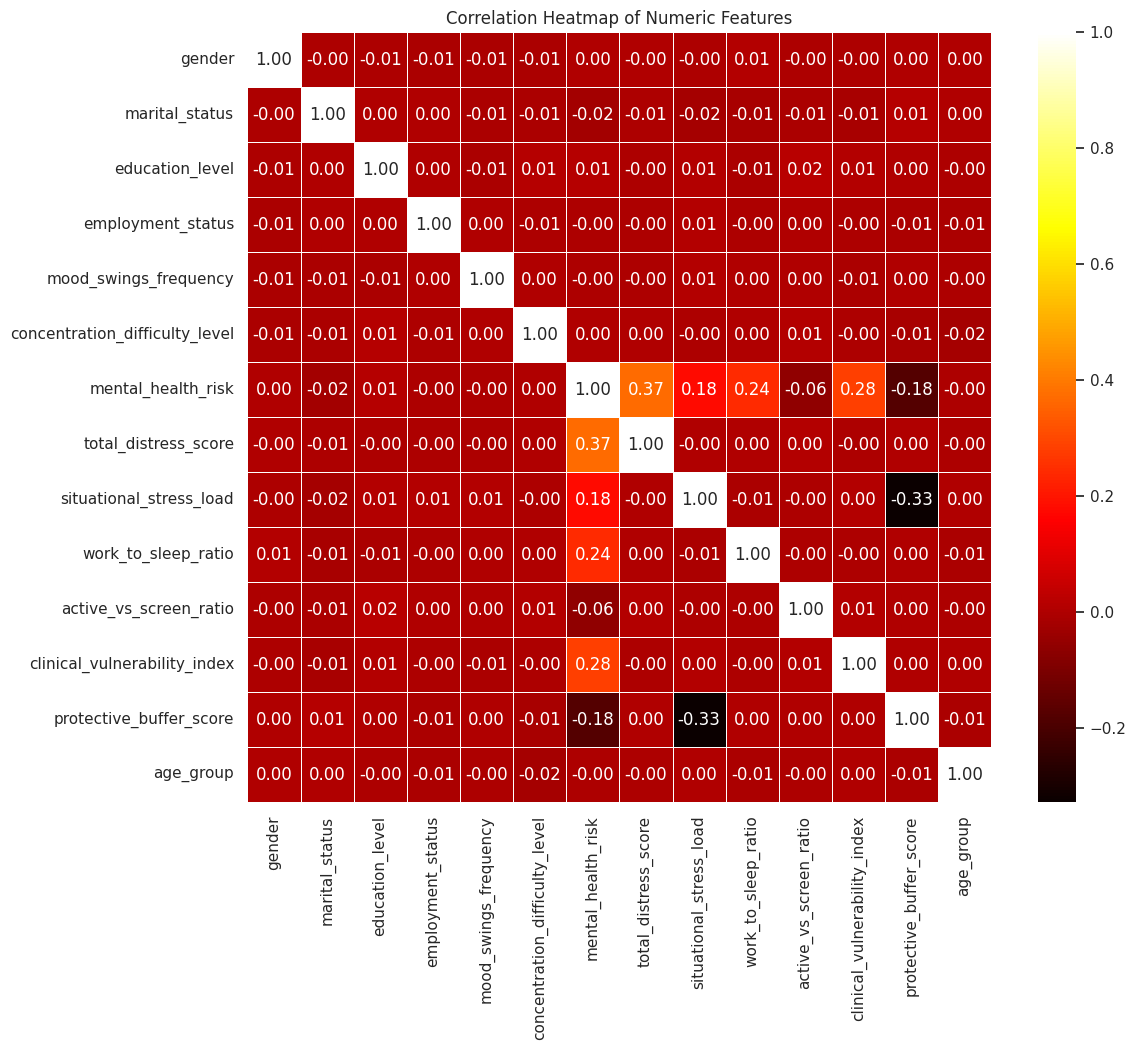

In [ ]:
# PLOT CORRELATION HEATMAP. FOR CORRELATION/HEAT MAP ANALYSIS USE THE TARGET
# VARIABLE WHICH WAS NOT NEEDED FOR PCA ANALYSIS
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.drop(columns='risk_level').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='hot', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


#OUTCOME

***The results show --> It will be better to use both categorical and numeric features as indicated in PC2 and PC4 in PCA(Categorical & Numerical - combined) analysis above.***



# USE PAIRPLOT TO CHECK THE CORELATION AMONGST NUMERICAL FEATURES ####

***Spliting features into parts to enhance readability***

Features to split: ['gender', 'marital_status', 'education_level', 'employment_status', 'mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'work_to_sleep_ratio', 'active_vs_screen_ratio', 'clinical_vulnerability_index', 'protective_buffer_score', 'age_group']
Total numerical features (excluding target for splitting): 13

Features for pairplot part 1: ['gender' 'marital_status' 'education_level' 'employment_status']


<Figure size 2000x1800 with 0 Axes>

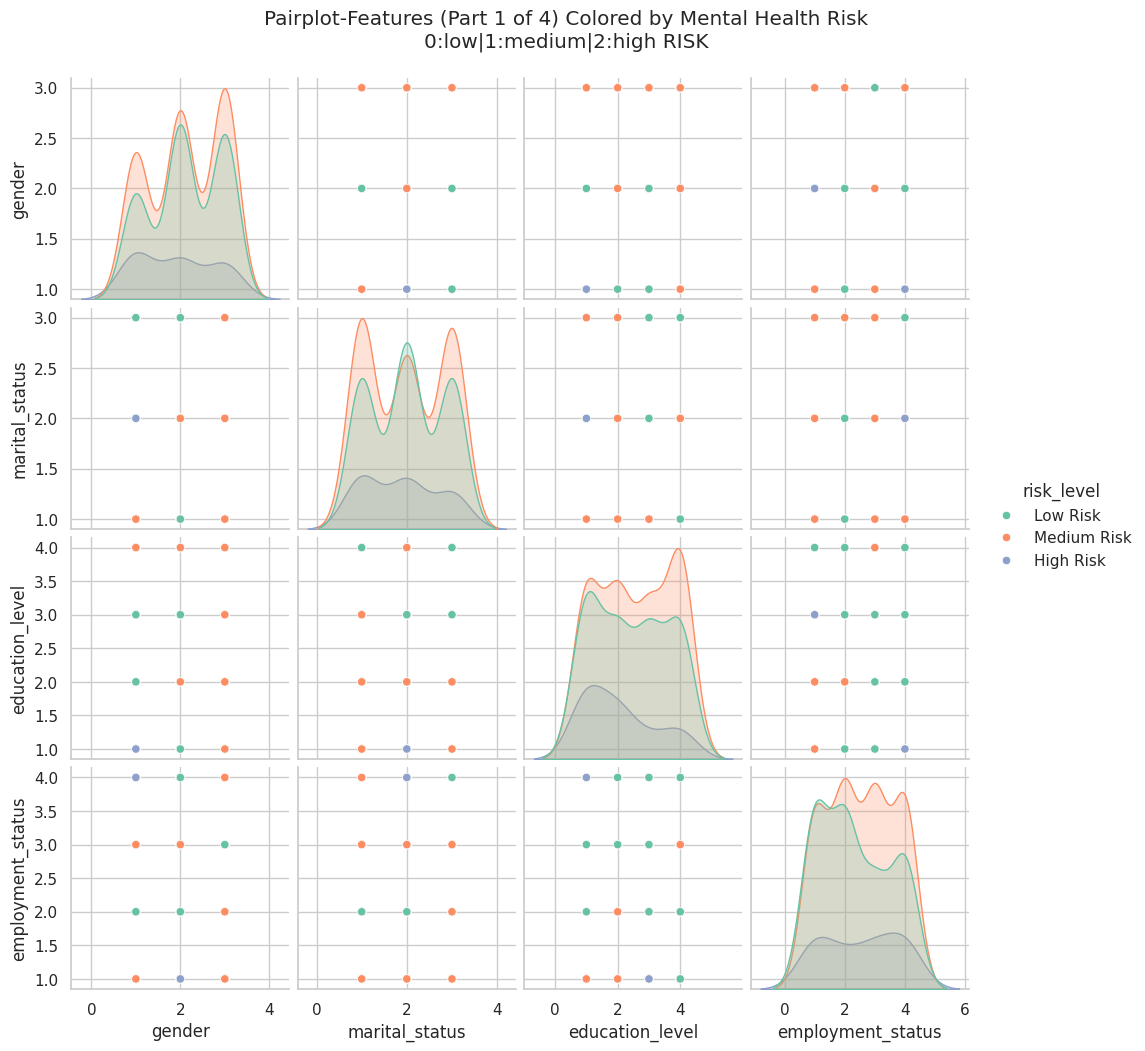


Features for pairplot part 2: ['mood_swings_frequency' 'concentration_difficulty_level'
 'total_distress_score']


<Figure size 2000x1800 with 0 Axes>

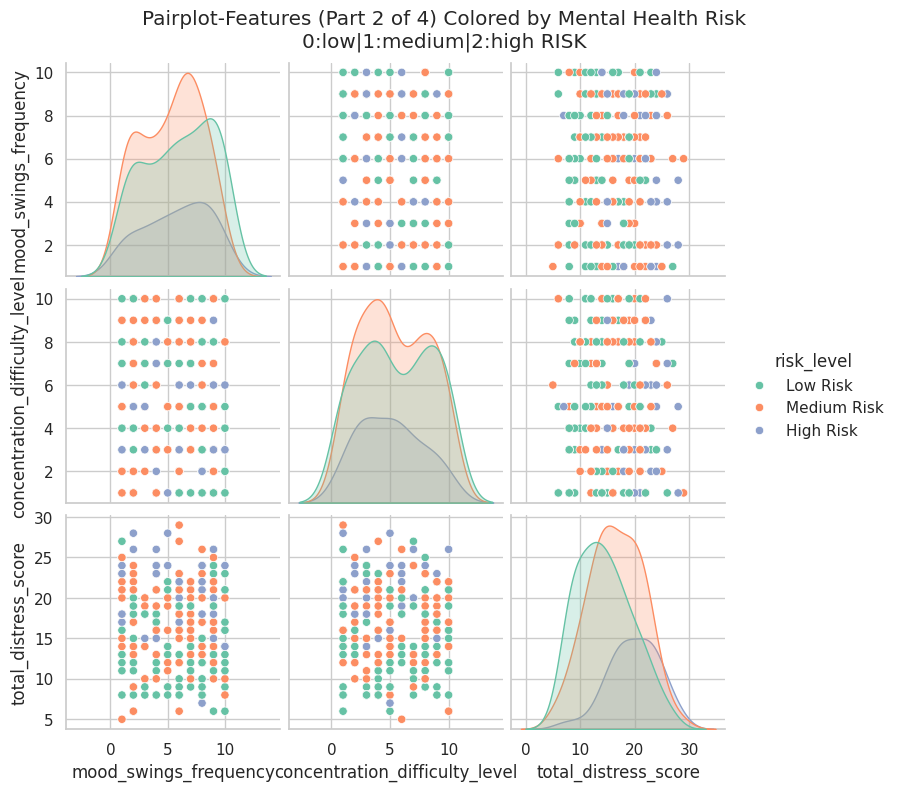


Features for pairplot part 3: ['situational_stress_load' 'work_to_sleep_ratio' 'active_vs_screen_ratio']


<Figure size 2000x1800 with 0 Axes>

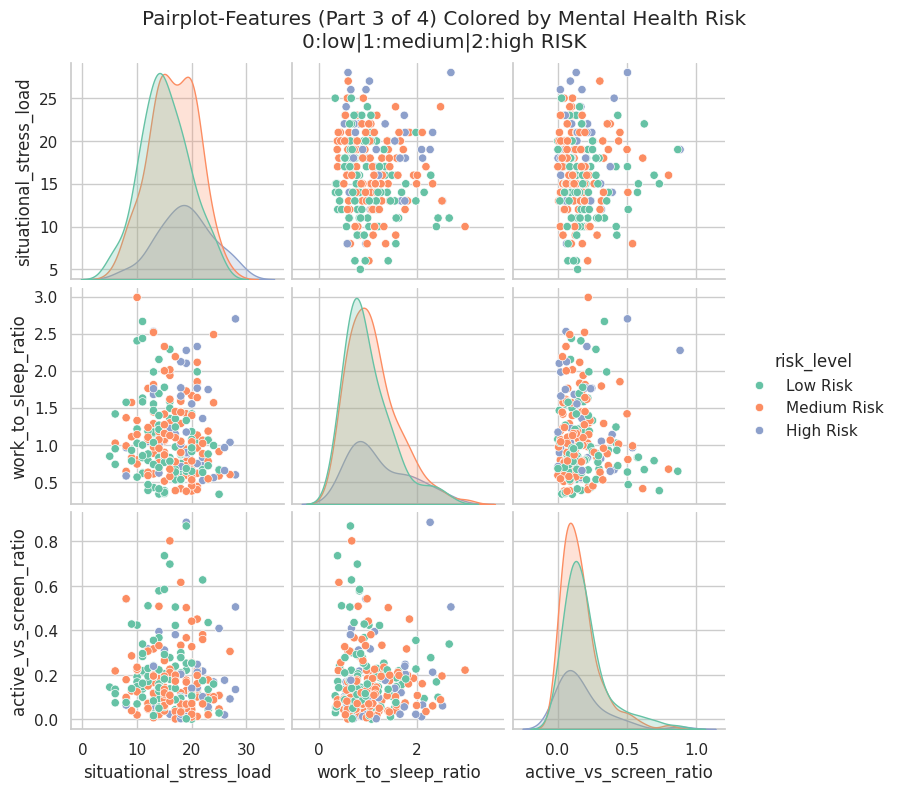


Features for pairplot part 4: ['clinical_vulnerability_index' 'protective_buffer_score' 'age_group']


<Figure size 2000x1800 with 0 Axes>

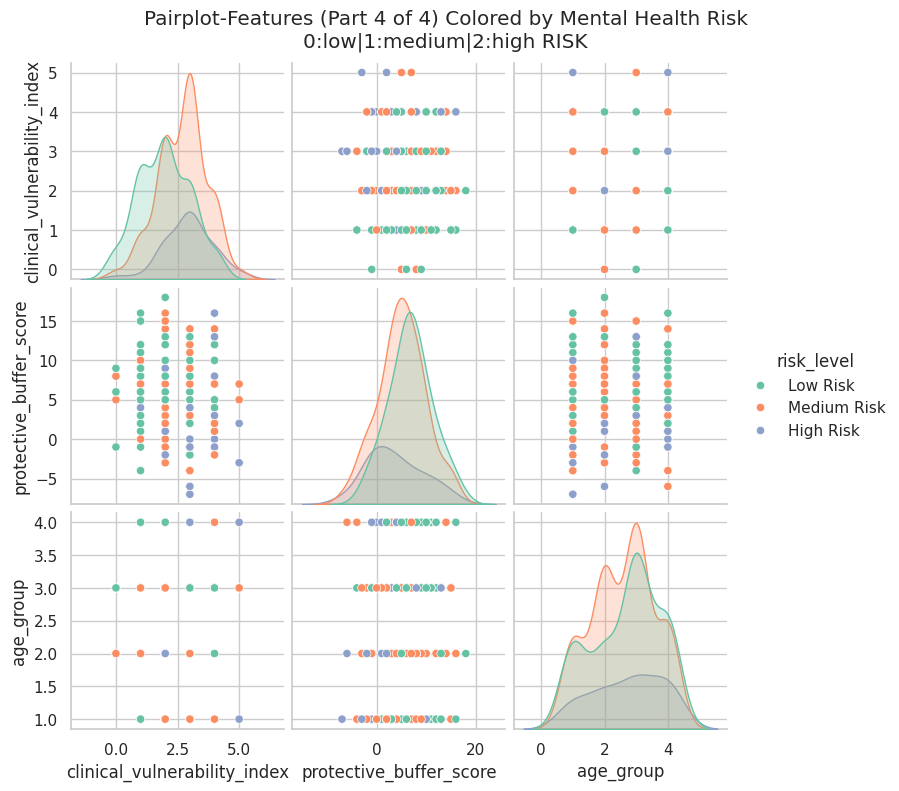

In [ ]:

# df_encoded has encoded categorical + numeric columns
# Filter out the target for the feature splitting part
# (mental_health_risk will be added back for 'hue' in pairplot)
features_to_split = [col for col in df_encoded.columns if col not in ['mental_health_risk','risk_level']]
num_features = len(features_to_split)
print(f"Features to split: {features_to_split}")
print(f"Total numerical features (excluding target for splitting): {num_features}")

# Determine the number of parts (quarters)
num_parts = 4

# Split features into 4 parts
feature_parts = np.array_split(features_to_split, num_parts)

# Loop through each part and create a pairplot
for i, part_features in enumerate(feature_parts):
    # Add the 'mental_health_risk' column to the current set of features for hue
    cols_for_pairplot = list(part_features) + ['risk_level']

    print(f"\nFeatures for pairplot part {i+1}: {part_features}")

    # Create the pairplot for the current part
    plt.figure(figsize=(20, 18)) # Adjust figure size as needed
    ax = sns.pairplot(df_encoded[cols_for_pairplot].sample(frac=0.01), hue="risk_level", palette="Set2")
    plt.suptitle(f"Pairplot-Features (Part {i+1} of {num_parts}) Colored by Mental Health Risk\n0:low|1:medium|2:high RISK\n\n", y=1.05)
    plt.show()


# Factors affecting algorithm selection

***Linear Separability (Clear Boundaries):***

What to look for: In the scatter plots (off-diagonal plots), if the different classes (colored by mental_health_risk) can be neatly separated by a straight line (or hyper-plane in higher dimensions), then the data is said to be linearly separable.
Algorithm suitability: If you see clear linear boundaries, algorithms like Logistic Regression, Linear SVM (Support Vector Machine), or Perceptron could be highly effective. They are efficient and provide interpretable models.

***Non-linear Separability (Complex Boundaries):***

What to look for: If the classes are intertwined, form concentric circles, or have boundaries that are clearly curved or irregular, then a linear model won't capture these relationships well.
Algorithm suitability: Algorithms that can handle non-linear decision boundaries will be more suitable. This includes Decision Trees, Random Forests, Gradient Boosting Machines (like XGBoost, LightGBM), Kernel SVM (e.g., RBF kernel), K-Nearest Neighbors (KNN), and Neural Networks.

***Distribution Overlap:***

What to look for: Observe the histograms or density plots (diagonal plots) and the scatter plots. If the distributions of different classes highly overlap for many features, it suggests the classification problem is inherently difficult.
Algorithm suitability: For high overlap, algorithms that are good at finding subtle patterns or that can handle uncertainty, such as ensemble methods (Random Forest, Gradient Boosting), Neural Networks, or more sophisticated SVMs, might be necessary. Feature engineering to create more separating features would also be crucial.

***Clusterability:***

What to look for: Do the data points for each class tend to form distinct 'clouds' or clusters, even if they're not perfectly linearly separable?
Algorithm suitability: Algorithms like K-Nearest Neighbors (KNN), which makes predictions based on the majority class of its nearest neighbors, can work well here. If the clusters are very distinct, even simple models might perform adequately after proper scaling.

***Outliers and Noise:***

What to look for: Are there many data points far removed from their respective class clusters, or are there points that seem to belong to one class but are deep within another class's region?
Algorithm suitability: Algorithms robust to outliers, such as Random Forests or Gradient Boosting Machines, tend to be less affected than models like linear regression or some SVMs. Data preprocessing to handle outliers might also be needed.

***Feature Scaling and Importance:***

What to look for: Look at the ranges of features. Are some features on a much larger scale than others? Also, observe which features show the clearest separation between classes.
Algorithm suitability: Algorithms sensitive to feature scaling (SVMs, KNN, Logistic Regression, Neural Networks) will require StandardScaler or MinMaxScaler. Tree-based models are generally less sensitive to scaling but can still benefit. Features that show clear separation in the plots are likely important for classification.
By carefully examining these visual cues in your pair plots, you can form an initial hypothesis about the complexity of your classification problem and which family of algorithms might be a good starting point for your modeling efforts.



# STEP 4:  MODELLING

# Start with LogisticRegression/KNN/SVM/DecisionTree- Identify Base model

## Include both categorical & numeric features to evaluate the if categorical feature makes any difference

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200),
    # "rf": RandomForestClassifier(),
    "SupportVectorMachine": SVC(probability=True),
    "DecisionTree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier()
}

metrics = {
        'Model': [],
        'Training Time': [],
        'Prediction Time': [],
        'Train Accuracy': [],
        'Test Accuracy': [],
        'Recall': [],
        'Confusion Matrix': [],
        'Classification Report': [],
        'ROC AUC': [],
        'F1': [],
        'Precision': []


        }

In [ ]:
# numerical_cols_generic_evaluation = [col for col in numeric_cols if col != ['mental_health_risk','active_vs_screen_ratio','work_to_sleep_ratio']]
# print(numerical_cols_generic_evaluation)
log_transformation_cols = ['active_vs_screen_ratio', 'work_to_sleep_ratio']
print(log_transformation_cols)
numerical_cols_generic_evaluation = [col for col in numeric_cols if col not in ['mental_health_risk','risk_level'] + log_transformation_cols]
print(numerical_cols_generic_evaluation)

['active_vs_screen_ratio', 'work_to_sleep_ratio']
['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']


# NUMERIC - STANDARD SCALAR
# CATEGORICAL - OneHotEncoder
# SKEWED FEATURE - LOG TRANSFORMATION

In [ ]:
from sklearn.preprocessing import FunctionTransformer
# ... (other imports)

column_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_generic_evaluation),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('log', FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one'), log_transformation_cols)
    ]
)

In [ ]:
print(f'numeric columns ={numerical_cols_generic_evaluation}')
print(f'numeric log transformation columns ={log_transformation_cols}')
print(f'categorical columns={categorical_cols}')

numeric columns =['mood_swings_frequency', 'concentration_difficulty_level', 'total_distress_score', 'situational_stress_load', 'clinical_vulnerability_index', 'protective_buffer_score']
numeric log transformation columns =['active_vs_screen_ratio', 'work_to_sleep_ratio']
categorical columns=['gender', 'marital_status', 'education_level', 'employment_status', 'age_group']


In [ ]:
X = mental_health_engineered_final_df.drop(columns=['mental_health_risk','risk_level'])
y = mental_health_engineered_final_df['mental_health_risk']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

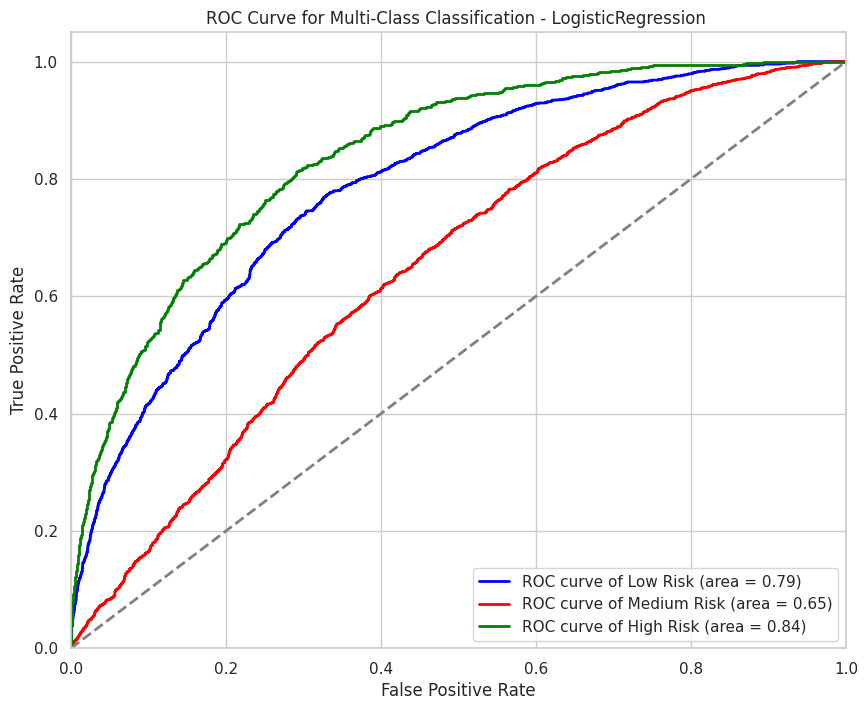

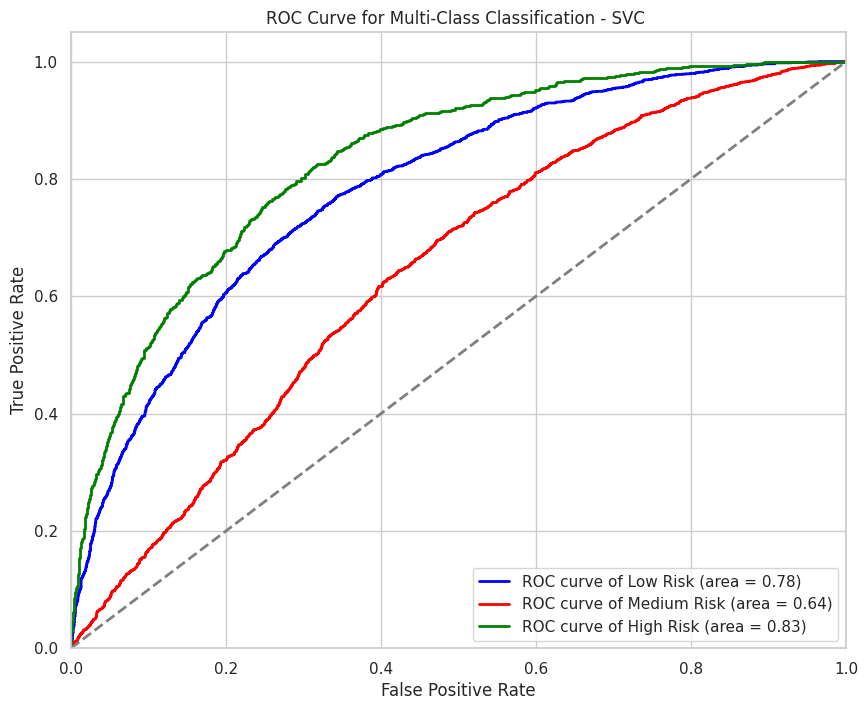

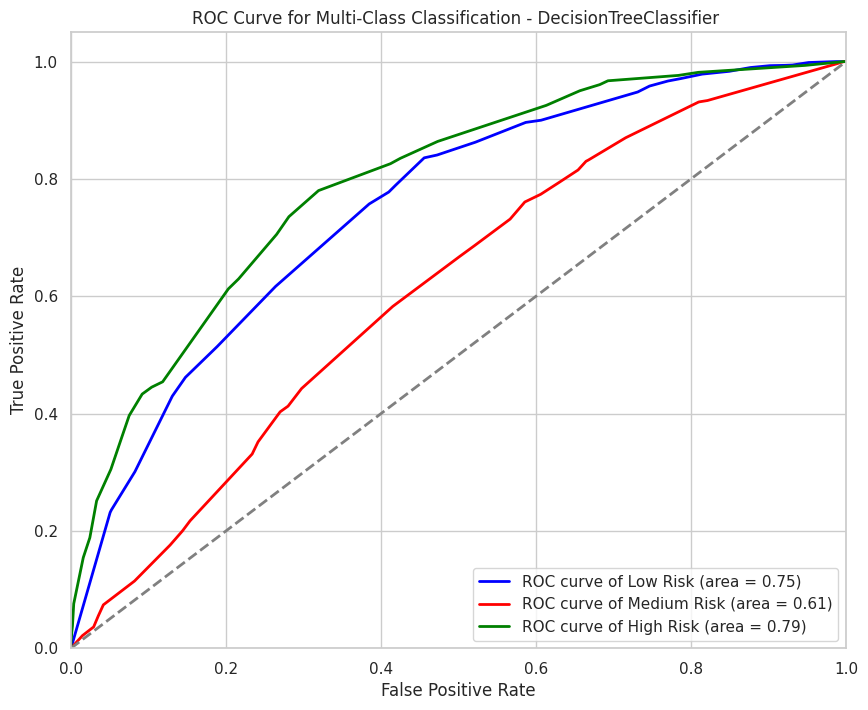

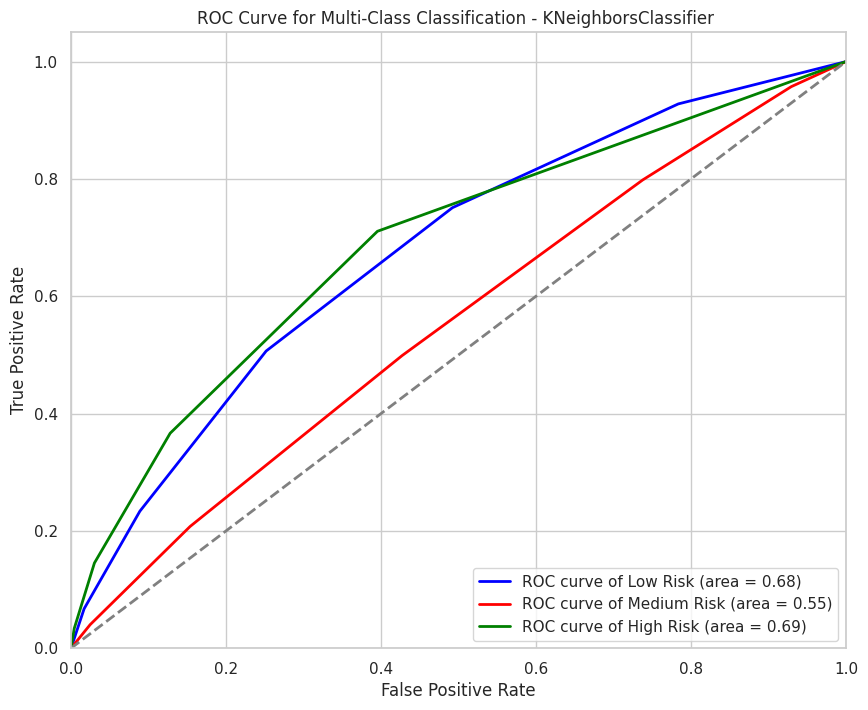

In [ ]:
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk'] # Define risk labels for better readability

for name, model in models.items():
    # Construct a pipeline with shared preprocessing steps + the specific model
    pipeline = Pipeline(steps=[('preprocessor', column_transformer),
                           ('model', model)
                           ])
    # Train the pipeline
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    # prediction time
    predict_start_time = time.time()
    y_pred = pipeline.predict(X_test)
    predict_end_time = time.time()
    predict_time = predict_end_time - predict_start_time

    # Evaluate
    score = pipeline.score(X_test, y_test) # remember accuracy_score(y_test,y_pred)
    # and pipeline.score(X_test,y_test) are same only they differ how they operate
    train_accuracy = pipeline.score(X_train, y_train)
    recall = recall_score(y_test, pipeline.predict(X_test),average='micro')
    confusion_mat = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred, target_names=risk_labels)
    roc_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test), multi_class='ovr')
    metrics['F1'].append(f1_score(y_test, y_pred, average='micro'))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='micro'))
    metrics['ROC AUC'].append(roc_auc)
    metrics['Confusion Matrix'].append(confusion_mat)
    metrics['Classification Report'].append(classification_rep)
    metrics['Model'].append(name)
    metrics['Test Accuracy'].append(score)
    metrics['Train Accuracy'].append(train_accuracy)
    metrics['Training Time'].append(train_time)
    metrics['Prediction Time'].append(predict_time)
    metrics['Recall'].append(recall)

    #Lets draw the ROC AUC curve for each class

    # Binarize the output for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_binarized.shape[1]
    # Compute ROC curve and ROC area for each class
    y_prob_roc = pipeline.predict_proba(X_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_roc[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Plot ROC curve for each class
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green']
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'ROC curve of {risk_labels[i]} (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class Classification - {type(pipeline.named_steps['model']).__name__} ')
    plt.legend(loc="lower right")
    plt.show()

    # print(f"{name} Accuracy: {score:.4f}")

In [ ]:
result_df_all_classifiers = pd.DataFrame(metrics)
result_df_all_classifiers

,Model,Training Time,Prediction Time,Train Accuracy,Test Accuracy,Recall,Confusion Matrix,Classification Report,ROC AUC,F1,Precision
0,LogisticRegression,0.69,0.07,0.61,0.60,0.60,"[[1084, 775, 12], [579, 1671, 115], [23, 510, ...",precision recall f1-score ...,0.76,0.60,0.60
1,SupportVectorMachine,130.07,4.43,0.64,0.59,0.59,"[[1029, 840, 2], [502, 1810, 53], [22, 610, 132]]",precision recall f1-score ...,0.75,0.59,0.59
2,DecisionTree,0.09,0.01,0.59,0.57,0.57,"[[864, 996, 11], [437, 1799, 129], [25, 547, 1...",precision recall f1-score ...,0.72,0.57,0.57
3,KNN,0.05,0.50,0.67,0.50,0.50,"[[1107, 741, 23], [971, 1289, 105], [159, 494,...",precision recall f1-score ...,0.64,0.50,0.50


## Results indicates generic classification algorithms are not showing good results. The accuracy and recall scores are NOT satisfatroy. For this use case we need higher recall score for low and medium RISK patients inorder NOT to miss potential mental health RISK  pateients. As a BASE model I will choose LogisticRegression.

* ROC-AUC curves indicates out of these FOUR models LogisticRegression is better compared to KNN,SVM & DecisionTree

* AUC for LogisticRegression
Low Risk = 0.79
Medium Risk = 0.65
High Risk = 0.85

* Restricted DecisionTree to max_depth =5 to ensure it does not overfit.

* Recall score is more important than accuraccy score

*  **From overall performace(Train/Test time) and recall/precision/F1-score perspective I will take LogisticRegression as my base model & look for other algorithm that can handle class imbalance & non linear relationships in a better way**